## Imports

In [2]:
# basic imports for data processing and plotting
import numpy as np
import pandas as pd
import logging as log
import os
import matplotlib.pyplot as plt
import unidecode


# imports for data loading
from nba_api.stats.endpoints import TeamGameLogs, PlayerGameLogs
import kagglehub

# sklearn imports for data splitting and model training
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_curve, balanced_accuracy_score
from sklearn.ensemble import GradientBoostingClassifier


## Define Constants

In [3]:
DATA_DIR = "data"
TEAMLOG_DATA = os.path.join(DATA_DIR, "team_data")
PLAYERLOG_DATA = os.path.join(DATA_DIR, "player_data")
INJURY_DATA = os.path.join(DATA_DIR, "injury_data")
PLOTS_DIR = "plots"
EXPLORE_DIR = os.path.join(PLOTS_DIR, '/exploration')
EVAL_DIR = os.path.join(PLOTS_DIR, '/evaluation')
SEASONS = ["2016-17", "2017-18", "2018-19", "2019-20", "2020-21", "2021-22", "2022-23", "2023-24"]
DEFAULT_COLUMNS = ['SEASON_YEAR', 'TEAM_ID', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'WL', 'MATCHUP']
# NUMERIC_COLUMNS = ['PTS', 'PLUS_MINUS', 'FG_PCT', 'FGM', 'OREB', 'DREB', 'AST', 'BLK']
NUMERIC_COLUMNS = ['FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
                   'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS']

WIN_PCT_COLUMN = 'WIN_PCT'
AGG_WINDOW_SIZES = [5, 15]
SEED = 42069
np.random.seed(SEED)


## Define helper functions

In [4]:
def check_create_dir(path):
    if os.path.exists(path):
        print(f"Directory {path} already exists.")
    else:
        os.makedirs(path)
        print(f"Directory {path} created.")

def load_from_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


## Data Loading

We desided on working with the NBA dataset through the nba_api plus an extra injury dataset which we uploaded to kaggle to improve the workflow.
While the nba_api has some documentation and quite clean data, it took some time to find out which data is of interest to us and how exactly we can acess it through the API - especially since the API didn't work in the cloud tool which we used for collaboration.
Therefore we had to switch to local environments, while handling the version control through github.

Our data consist of the following tables:

- **Injury_data:** All injury related events in the NBA from 2016 - 2025: Date; Player_name; Team_name; placed on IL (Injury List) or activated from IL

- **Player_data:** All game stats per player and corresponding game. - Game_id; Player_name; Game_info: Winner/Looser, Matchup, home/away; Game_stats: FGM, FGA, FG3M, FG3A, FTM, FTA, OREB, DREB, AST, STL, BLK, TO, PF, PTS, PLUS_MINUS

- **Team_data:** All game stats per team and corresponding game. *Same as for players just aggregated* - Game_id; Team_name; Game_info; Game_stats


In [5]:
log.basicConfig(level=log.INFO,
                format='%(asctime)s: %(levelname)s: %(message)s',
                datefmt='%Y-%m-%d %H:%M:%S')


def load_injury_data() -> pd.DataFrame:
    # Download latest version
    path = kagglehub.dataset_download("jacquesoberweis/2016-2025-nba-injury-data")

    print("Path to dataset files:", path)
    df = pd.read_csv(os.path.join(path, "injury_data.csv"))
    return df


def load_playerlogs(seasons: list[str]) -> pd.DataFrame:
    df = pd.DataFrame()
    for season in seasons:
        gamedatapull = PlayerGameLogs(
            league_id_nullable="00",  # nba 00, g_league 20, wnba 10
            season_type_nullable="Regular Season",  # Regular Season, Playoffs, Pre Season
            season_nullable=season,
        )

        df_season = gamedatapull.get_data_frames()[0]
        df = pd.concat([df, df_season])
    return df


def load_teamlogs(seasons: list[str]) -> pd.DataFrame:
    df = pd.DataFrame()
    for season in seasons:
        gamedatapull = TeamGameLogs(
            league_id_nullable="00",  # nba 00, g_league 20, wnba 10
            season_type_nullable="Regular Season",  # Regular Season, Playoffs, Pre Season
            season_nullable=season,
        )

        df_season = gamedatapull.get_data_frames()[0]
        df = pd.concat([df, df_season])
    return df



team_data = load_teamlogs(SEASONS)
#team_data.to_csv(os.path.join(TEAMLOG_DATA, "team_data.csv"), index=False)
log.info("Team data loaded into team_data")
log.info(team_data.head())

player_data = load_playerlogs(SEASONS)
#player_data.to_csv(os.path.join(PLAYERLOG_DATA, "player_data.csv"), index=False)
log.info("Player data loaded")
log.info(player_data.head())

injury_data = load_injury_data()
#injury_data.to_csv(os.path.join(INJURY_DATA, "injury_data.csv"), index=False)
log.info("Injury data loaded")
log.info(injury_data.head())


2025-01-26 15:12:37: INFO: Team data loaded into team_data
2025-01-26 15:12:37: INFO:   SEASON_YEAR     TEAM_ID TEAM_ABBREVIATION          TEAM_NAME     GAME_ID  \
0     2016-17  1610612743               DEN     Denver Nuggets  0021601225   
1     2016-17  1610612752               NYK    New York Knicks  0021601220   
2     2016-17  1610612763               MEM  Memphis Grizzlies  0021601223   
3     2016-17  1610612761               TOR    Toronto Raptors  0021601218   
4     2016-17  1610612737               ATL      Atlanta Hawks  0021601226   

             GAME_DATE      MATCHUP WL   MIN  FGM  ...  AST_RANK  TOV_RANK  \
0  2017-04-12T00:00:00    DEN @ OKC  W  48.0   39  ...      1222      1857   
1  2017-04-12T00:00:00  NYK vs. PHI  W  48.0   41  ...      2076      2148   
2  2017-04-12T00:00:00  MEM vs. DAL  L  48.0   33  ...      1933      1413   
3  2017-04-12T00:00:00    TOR @ CLE  W  48.0   40  ...      1584       178   
4  2017-04-12T00:00:00    ATL @ IND  L  48.0   30  ... 

100%|██████████| 147k/147k [00:00<00:00, 678kB/s]

Extracting model files...



2025-01-26 15:12:50: INFO: Injury data loaded
2025-01-26 15:12:50: INFO:          Date       Team Acquired                 Relinquished  \
0  2016-10-25    Blazers      NaN                 Festus Ezeli   
1  2016-10-25    Blazers      NaN               Tim Quarterman   
2  2016-10-25  Cavaliers      NaN   Kahlil Felder / Kay Felder   
3  2016-10-25       Jazz      NaN                   Alec Burks   
4  2016-10-25       Jazz      NaN               Gordon Hayward   

                                               Notes  
0  placed on IL with sore left knee (out for season)  
1                                       placed on IL  
2                       placed on IL with concussion  
3                         placed on IL with sore leg  
4       placed on IL with fractured left ring finger  


Path to dataset files: /Users/joey/.cache/kagglehub/datasets/jacquesoberweis/2016-2025-nba-injury-data/versions/5


## Preprocessing and Feature Engineering

In the following functions we preprocess our data.
The biggest part here was to merge the whole data together and to get it in a format which we can feed into our model, aswell as to find out which features are of interest and how we can use them to forge new features, which incldude additional information - focusing on injured players, since we expected it to be a reasonable factor in the performance of a team.

### Proprocess Team Data

Our Preprocessing pipeline starts with cooperating some transformations on the team data.

- **convert_dtypes_teamlogs** standardizes the data types of specific columns, ensuring consistency by converting years to integers, team names to strings, dates to datetime objects, and binary indicators appropriately. 

- **compute_rolling_values** calculates rolling aggregate statistics (like the mean) for numeric columns over a specified window size, grouped by team and season, which helps in capturing performance trends over time. 

- **aggregate_team_stats** organizes the data chronologically, applies multiple rolling window aggregations, computes win percentages, and removes initial rows that don’t meet the window size criteria to prepare the dataset for analysis. 
The information that is generated through this function and the rolling window is fundamental for our model. The idea was to aggregate all important information for each team and its past n (we used two windows: 5 and 15) games, including the win percentage,  which will enable us to feed the model with the most recent information about the teams, since we expect the most recent games to be the most important for the prediction of the next game.
As we proceed to the next season, we decided on resetting the rolling window, since we expect the teams to have changed and the information from the last season to be less relevant.

- **combine_on_gameid** separates the dataset into home and away teams, drops unnecessary columns, and merges them based on the game identifier to create a unified view of each game from both perspectives. - Now we have all the information we need for each game in one row.

- **preprocess_teamlogs** orchestrates the entire workflow by loading the data, cleaning and converting data types, handling missing values, aggregating statistics, combining team data, and saving the processed datasets for further use.

In [6]:
def convert_dtypes_teamlogs(df: pd.DataFrame, numeric_cols=None) -> pd.DataFrame:
    df = df.copy()
    df['SEASON_YEAR'] = df['SEASON_YEAR'].str[:4].astype(int)
    df['TEAM_NAME'] = df['TEAM_NAME'].astype('string')
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    df['HOME'] = df['MATCHUP'].str.contains(r'\bvs\b').astype(int)
    df.drop(columns=['MATCHUP'], inplace=True)
    df['WL'] = df['WL'].map({'W': 1, 'L': 0}).astype(int)
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                if (df[col].dtype == 'int64' or df[col].dtype == 'float64') and col in df.columns:
                    df[col] = df[col].astype(float)
        return df
    else:
        return df



def compute_rolling_values(df: pd.DataFrame,
                           window_size: int,
                           agg_function=lambda x: np.mean(x),
                           group: list[str] = ['TEAM_ID', 'SEASON_YEAR']) -> pd.DataFrame:
    df = df.copy()
    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            colname = col + '_AGG_' + str(window_size)
            df[colname] = df.groupby(group)[col].transform(
                lambda x: x.shift(1).rolling(window=window_size, min_periods=1).agg(agg_function))
    return df


def aggregate_team_stats(df: pd.DataFrame) -> pd.DataFrame:
    # sort by date
    df = df.sort_values(by=['GAME_DATE'])

    for window_size in AGG_WINDOW_SIZES:
        df = compute_rolling_values(df, window_size, agg_function=lambda x: np.mean(x))

    df = df.drop(columns=NUMERIC_COLUMNS, inplace=False)
    # Calculate season long win percentage
    df[WIN_PCT_COLUMN] = df.groupby(['TEAM_ID', 'SEASON_YEAR'])['WL'].transform(
        lambda x: x.shift(1).rolling(window=9999, min_periods=1).mean())

    # Drop first window_size rows for each team
    df = df.groupby(['TEAM_ID', 'SEASON_YEAR']).apply(
        lambda x: x.iloc[window_size:],
        include_groups=False
    ).reset_index(['TEAM_ID', 'SEASON_YEAR'], drop=False)

    return df

def combine_on_gameid(df) -> pd.DataFrame:
    if 'TEAM_NAME' in df.columns:
        df = df.drop(columns=['TEAM_NAME'], inplace=False)

    df_HOME = df[df['HOME'] == 1]
    df_AWAY = df[df['HOME'] == 0]
    df_HOME = df_HOME.drop(columns=['HOME'], inplace=False)
    df_AWAY = df_AWAY.drop(columns=['HOME', 'SEASON_YEAR', 'GAME_DATE', 'WL'], inplace=False)

    df_merged = df_HOME.merge(df_AWAY, on='GAME_ID', suffixes=('_HOME', '_AWAY'))

    #df_merged.set_index(['SEASON_YEAR', 'GAME_ID', 'GAME_DATE', 'TEAM_ID_HOME', 'TEAM_ID_AWAY'], inplace=True)

    return df_merged


def preprocess_teamlogs(df=None) -> pd.DataFrame:
    if df is None:
        log.info("Loading data from csv")
        df = load_from_csv(os.path.join(TEAMLOG_DATA, "team_data.csv"))
    log.info(df.head())

    log.info(df['TEAM_NAME'].unique())

    # drop variables that end with "_RANK"
    df = df.loc[:, ~df.columns.str.endswith('_RANK')]
    df = df.drop(columns=['AVAILABLE_FLAG'], inplace=False)

    # create data with all columns converted to appropriate data types
    df_team_converted = convert_dtypes_teamlogs(df)
    #df_full_converted.to_csv(os.path.join(TEAMLOG_DATA, 'team_data_full_converted.csv'), index=False)

    # create mapping from team name to team id and save to json file
    team_mapping = df_team_converted[['TEAM_NAME', 'TEAM_ID']].drop_duplicates()
    team_mapping.to_json(os.path.join('mappings', 'team_id_mapping.json'), orient='records')

    COLUMNS = DEFAULT_COLUMNS + NUMERIC_COLUMNS
    df = df[COLUMNS]

    log.info("Checking for missing values")
    missing_values = df.isnull().sum()
    log.info(missing_values)

    df = convert_dtypes_teamlogs(df, NUMERIC_COLUMNS)
    df.sort_values(by=['GAME_DATE', 'GAME_ID'], inplace=True)
    df.to_csv(os.path.join(TEAMLOG_DATA, 'team_data_converted.csv'), index=False)

    df = aggregate_team_stats(df)
    df.to_csv(os.path.join(TEAMLOG_DATA, 'team_data_aggregated.csv'), index=False)

    df = combine_on_gameid(df)
    return df, df_team_converted 
    df.to_csv(os.path.join(TEAMLOG_DATA, 'team_data_combined.csv'), index=True)

df_team, df_team_converted = preprocess_teamlogs(team_data)
df_team.head()


2025-01-26 16:21:22: INFO:   SEASON_YEAR     TEAM_ID TEAM_ABBREVIATION          TEAM_NAME     GAME_ID  \
0     2016-17  1610612743               DEN     Denver Nuggets  0021601225   
1     2016-17  1610612752               NYK    New York Knicks  0021601220   
2     2016-17  1610612763               MEM  Memphis Grizzlies  0021601223   
3     2016-17  1610612761               TOR    Toronto Raptors  0021601218   
4     2016-17  1610612737               ATL      Atlanta Hawks  0021601226   

             GAME_DATE      MATCHUP WL   MIN  FGM  ...  AST_RANK  TOV_RANK  \
0  2017-04-12T00:00:00    DEN @ OKC  W  48.0   39  ...      1222      1857   
1  2017-04-12T00:00:00  NYK vs. PHI  W  48.0   41  ...      2076      2148   
2  2017-04-12T00:00:00  MEM vs. DAL  L  48.0   33  ...      1933      1413   
3  2017-04-12T00:00:00    TOR @ CLE  W  48.0   40  ...      1584       178   
4  2017-04-12T00:00:00    ATL @ IND  L  48.0   30  ...      1762      2250   

   STL_RANK  BLK_RANK  BLKA_RANK  P

,TEAM_ID_HOME,SEASON_YEAR,GAME_ID,GAME_DATE,WL,FGM_AGG_5_HOME,FGA_AGG_5_HOME,FG_PCT_AGG_5_HOME,FG3M_AGG_5_HOME,FG3A_AGG_5_HOME,...,AST_AGG_15_AWAY,TOV_AGG_15_AWAY,STL_AGG_15_AWAY,BLK_AGG_15_AWAY,BLKA_AGG_15_AWAY,PF_AGG_15_AWAY,PFD_AGG_15_AWAY,PTS_AGG_15_AWAY,PLUS_MINUS_AGG_15_AWAY,WIN_PCT_AWAY
0,1610612737,2016,0021600288,2016-12-02,0,36.4,86.0,0.4220,8.2,26.8,...,20.600000,10.933333,6.533333,4.133333,5.133333,17.600000,16.533333,99.200000,0.666667,0.500000
1,1610612737,2016,0021600307,2016-12-05,0,37.4,87.6,0.4270,8.2,28.2,...,23.533333,15.066667,6.933333,5.200000,5.066667,19.933333,19.133333,109.266667,2.133333,0.619048
2,1610612737,2016,0021600324,2016-12-07,1,36.4,85.4,0.4268,7.2,25.6,...,19.933333,12.000000,7.533333,5.600000,6.066667,20.133333,18.466667,97.800000,-2.400000,0.333333
3,1610612737,2016,0021600369,2016-12-13,0,36.8,85.0,0.4338,7.2,25.4,...,20.400000,13.666667,6.933333,5.866667,5.733333,18.200000,18.000000,94.666667,-2.733333,0.400000
4,1610612737,2016,0021600401,2016-12-17,0,41.6,84.8,0.4896,9.0,25.6,...,22.200000,12.666667,5.466667,5.066667,5.733333,16.133333,20.666667,102.000000,-1.000000,0.518519


### Preprocess Player Data

- **convert_dtypes_playerlogs:** Converts the data types of specific columns

- **preprocess_stats:** Standardizes column names and formatts PLAYER_NAME to be in same format as the PLAYER_NAME in the injury data (using unidecode to get rid of special characters)

In [14]:
def convert_dtypes_playerlogs(df: pd.DataFrame, numeric_cols=None) -> pd.DataFrame:
    df = df.copy()
    df = df[['SEASON_YEAR', 'PLAYER_ID', 'PLAYER_NAME', 'GAME_DATE', 'MIN', 'PTS', 'PLUS_MINUS']]
    df['SEASON_YEAR'] = df['SEASON_YEAR'].str[:4].astype(int)
    df['PLAYER_ID'] = df['PLAYER_ID'].astype(int)
    df['PLAYER_NAME'] = df['PLAYER_NAME'].astype('string')
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
    df['MIN'] = df['MIN'].astype(float)
    df['PTS'] = df['PTS'].astype(float)
    df['PLUS_MINUS'] = df['PLUS_MINUS'].astype(float)
    return df


def preprocess_stats(df=None):
    if df is None:
        log.info("Loading data from csv")
        df = load_from_csv(os.path.join(PLAYERLOG_DATA, "player_data.csv"))
    df["Season"] = df["SEASON_YEAR"].apply(lambda x: int(x[:4]))
    df["Team"] = df["TEAM_ABBREVIATION"].astype(str)
    df["Player"] = df["PLAYER_NAME"].astype(str)
    df["Player"] = df["Player"].apply(lambda x: unidecode.unidecode(x))

    df.drop(columns=["SEASON_YEAR", "PLAYER_NAME"], inplace=True)
    df.columns = df.columns.str.upper()
    return df
    df.to_csv(os.path.join(PLAYERLOG_DATA, "player_data_cleaned.csv"), index=False)

""" def preprocess_player_logs():

    def aggregate_player_stats(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df.sort_values(by=['GAME_DATE', 'PLAYER_NAME'])
        df = compute_rolling_values(df, 9999, agg_function=lambda x: np.mean(x), group=['PLAYER_ID', 'SEASON_YEAR'])

        return df

    log.info("Loading data from csv")
    df = load_from_csv(os.path.join(PLAYERLOG_DATA, "player_data.csv"))
    log.info(df.head())
    create_player_mapping(df)

    # drop variables that end with "_RANK"
    df = convert_dtypes_playerlogs(df)

    # create data with all columns converted to appropriate data types
    df.to_csv(os.path.join(PLAYERLOG_DATA, 'player_data_converted.csv'), index=False)

    df = aggregate_player_stats(df)
    df.to_csv(os.path.join(PLAYERLOG_DATA, 'player_data_aggregated.csv'), index=False)


def create_player_mapping(df: pd.DataFrame):
    # create json file containing player name to player id mapping
    player_mapping = df[['PLAYER_NAME', 'PLAYER_ID']].drop_duplicates()
    player_mapping.to_json(os.path.join(DATA_DIR, 'player_mapping.json'), orient='records')
 """

df_player = preprocess_stats(player_data)
df_player.head()

,PLAYER_ID,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,...,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,SEASON,TEAM,PLAYER
0,201582,Alexis,1610612740,NOP,New Orleans Pelicans,0021601230,2017-04-12T00:00:00,NOP @ POR,W,25.170000,...,10057,12157,2032,118,10793,1.0,25:10,2016,NOP,Alexis Ajinca
1,202683,Enes,1610612760,OKC,Oklahoma City Thunder,0021601225,2017-04-12T00:00:00,OKC vs. DEN,L,19.850000,...,5259,11408,2032,118,10793,1.0,19:51,2016,OKC,Enes Freedom
2,201580,JaVale,1610612744,GSW,Golden State Warriors,0021601229,2017-04-12T00:00:00,GSW vs. LAL,W,17.850000,...,4644,9459,2032,118,10056,1.0,17:51,2016,GSW,JaVale McGee
3,200768,Kyle,1610612761,TOR,Toronto Raptors,0021601218,2017-04-12T00:00:00,TOR @ CLE,W,17.150000,...,3615,13660,2032,118,10793,1.0,17:09,2016,TOR,Kyle Lowry
4,203490,Otto,1610612764,WAS,Washington Wizards,0021601221,2017-04-12T00:00:00,WAS @ MIA,L,14.683333,...,20002,13038,2032,118,13020,1.0,14:41,2016,WAS,Otto Porter Jr.


### Preprocess Injury 

The **preprocess_injury_data** function processes player injury records by identifying when players are placed on or removed from the Injured List (IL). Specifically, it interprets the “Relinquished” column as the date a player was placed on the IL and the “Acquired” column as the date they were removed from the IL. A key issue addressed by the function is the absence of “Acquired” dates for some players who were relinquished again without an acquisition record, presumably happening because they acquired from the IL during the season pause. To resolve this, the function assigns the end of the season as the “Acquired” date for these cases, ensuring that every injury period has both a start and an end date.

The function adds “Injury_Start” and “Injury_End” columns to capture the duration of each player’s injury period. It cleans and standardizes player and team names by removing special characters. It also dublicated some rows, which have two names in the PLAYER_NAME column, giving each name one row. Additionally, it merges team and player IDs using predefined mappings to maintain consistency across the dataset. The resulting DataFrame is organized chronologically, ensuring that injury periods are accurately tracked over time. Finally, the function returns a cleaned and comprehensive DataFrame that includes complete injury periods for each player, with the unique PLAYER_NAME as the primary identifier, which will be used to merge the injury data with the team and player logs.

In [17]:
def preprocess_injury_data(df=None) -> pd.DataFrame:
    if df is None:
        log.info("Loading data from csv")
        df = load_from_csv(os.path.join(INJURY_DATA, "injury_data.csv"))

    df["Date"] = pd.to_datetime(
        df["Date"], format="%Y-%m-%d", errors="coerce"
    )

    players = []
    if "Relinquished" in df.columns:
        players = df["Relinquished"].dropna().unique().tolist()

    injury_start = df[df["Relinquished"].notna()][
        ["Date", "Team", "Relinquished", "Notes"]
    ].rename(columns={"Date": "Injury_Start", "Relinquished": "Player"})

    injury_end = df[df["Acquired"].notna()][
        ["Date", "Team", "Acquired"]
    ].rename(columns={"Date": "Injury_End", "Acquired": "Player"})

    result = []
    for player, group in injury_start.groupby("Player"):
        injury_group = group.sort_values(by="Injury_Start")
        recovery_group = injury_end[injury_end["Player"] == player].sort_values(
            by="Injury_End"
        )
        recovery_dates = iter(recovery_group["Injury_End"])

        current_recovery = None
        try:
            current_recovery = next(recovery_dates)
        except StopIteration:
            pass

        for i, (index, injury_row) in enumerate(injury_group.iterrows()):
            injury_note = injury_row["Notes"] if pd.notna(injury_row["Notes"]) else ""
            current_injury = injury_row["Injury_Start"]

            # Calculate season-ending date if applicable
            injury_end_date = pd.NaT
            if "(out for season)" in injury_note.lower():
                current_year = current_injury.year
                august_15_current_year = pd.Timestamp(f"{current_year}-08-15")

                if current_injury > august_15_current_year:
                    injury_end_date = pd.Timestamp(f"{current_year + 1}-08-15")
                else:
                    injury_end_date = august_15_current_year

            if i + 1 < len(injury_group):
                next_injury = injury_group.iloc[i + 1]["Injury_Start"]
                if current_recovery and current_recovery > next_injury:
                    result.append(
                        {
                            "Player": player,
                            "Team": injury_row["Team"],
                            "Injury_Start": current_injury,
                            "Injury_End": injury_end_date,
                            "Injury_Notes": injury_note,
                        }
                    )
                else:
                    end_date = (
                        injury_end_date
                        if not pd.isna(injury_end_date)
                        else current_recovery
                    )
                    result.append(
                        {
                            "Player": player,
                            "Team": injury_row["Team"],
                            "Injury_Start": current_injury,
                            "Injury_End": end_date,
                            "Injury_Notes": injury_note,
                        }
                    )
                    try:
                        current_recovery = next(recovery_dates)
                    except StopIteration:
                        current_recovery = None
            else:
                if current_recovery and current_recovery > current_injury:
                    end_date = current_recovery
                else:
                    end_date = (
                        injury_end_date if not current_recovery else current_recovery
                    )

                result.append(
                    {
                        "Player": player,
                        "Team": injury_row["Team"],
                        "Injury_Start": current_injury,
                        "Injury_End": end_date,
                        "Injury_Notes": injury_note,
                    }
                )

    # Convert to DataFrame and clean up
    result_df = pd.DataFrame(result)

    # Iterating backwards to combine injuries that are consecutive, and fixing those that are season ending without having knowledge of it at the time
    for i in range(len(result_df) - 1, -1, -1):
        # Check if current row has NaT in Injury_End
        if pd.isna(result_df.iloc[i]["Injury_End"]):
            current_injury_start = result_df.iloc[i]["Injury_Start"]
            current_player = result_df.iloc[i]["Player"]

            # Get the next August 15 after Injury_Start
            current_year = current_injury_start.year
            august_15_current_year = pd.Timestamp(f"{current_year}-08-15")

            if current_injury_start > august_15_current_year:
                default_injury_end = pd.Timestamp(f"{current_year + 1}-08-15")
            else:
                default_injury_end = august_15_current_year

            # Check if there's a row below (i < len(df) - 1) and if names match
            if (
                i < len(result_df) - 1
                and current_player == result_df.iloc[i + 1]["Player"]
            ):
                next_injury_start = result_df.iloc[i + 1]["Injury_Start"]
                next_august_15 = pd.Timestamp(f"{current_injury_start.year}-08-15")
                if current_injury_start > next_august_15:
                    next_august_15 = pd.Timestamp(
                        f"{current_injury_start.year + 1}-08-15"
                    )

                # Check if next injury starts before next August 15
                if next_injury_start <= next_august_15:
                    # Combine rows by taking end date from next row
                    result_df.at[i, "Injury_End"] = result_df.iloc[i + 1]["Injury_End"]
                    # Combine injury notes if they exist
                    if pd.notna(result_df.iloc[i + 1]["Injury_Notes"]):
                        result_df.at[i, "Injury_Notes"] = (
                            str(result_df.iloc[i]["Injury_Notes"])
                            + " ; "
                            + str(result_df.iloc[i + 1]["Injury_Notes"])
                        )
                    # Drop the next row as it's now combined
                    result_df = result_df.drop(index=result_df.index[i + 1])
                else:
                    # Set end date to next August 15
                    result_df.at[i, "Injury_End"] = default_injury_end
            else:
                # Set end date to next August 15
                result_df.at[i, "Injury_End"] = default_injury_end

    result_df["Team"] = result_df["Team"].astype(str)
    result_df["Player"] = result_df["Player"].astype(str).str.strip()
    result_df["Injury_Notes"] = result_df["Injury_Notes"].astype(str).str.strip()

    # Load mappings
    team_name_mapping = pd.read_json(os.path.join('mappings', 'team_name_mapping.json'))
    team_id_mapping = pd.read_json(os.path.join('mappings', 'team_id_mapping.json'))
    player_mapping = pd.read_json(os.path.join('mappings', 'player_mapping.json'))

    # Mapping Team Name to Team ID
    result_df = result_df.merge(team_name_mapping, left_on='Team', right_on='Team', how='left')
    result_df = result_df.drop(columns=['Team'], inplace=False)
    result_df.rename(columns={'TEAM_NAME': 'TEAM'}, inplace=True)
    result_df = result_df.merge(team_id_mapping, left_on='TEAM', right_on='TEAM_NAME', how='left')
    result_df = result_df.drop(columns=['TEAM', 'TEAM_NAME'], inplace=False)

    # from "Player" column remove string that are contained in brackets ()
    result_df["Player"] = result_df["Player"].str.replace(r"\(.*\)", "", regex=True)
    # Split a row where the name contatins "/" into two rows
    result_df = result_df.assign(
        Player=result_df["Player"].str.split("/")).explode("Player")
    result_df["Player"] = result_df["Player"].str.strip()

    # turn into datetime
    result_df["Injury_Start"] = pd.to_datetime(result_df["Injury_Start"])
    result_df["Injury_End"] = pd.to_datetime(result_df["Injury_End"])

    # rename columns into Caps
    result_df.columns = result_df.columns.str.upper()

    result_df = result_df.sort_values(["PLAYER", "INJURY_START"])
    result_df = result_df.reset_index(drop=True)


    #result_df.to_csv(os.path.join(INJURY_DATA, "injury_data_cleaned.csv"), index=False)
    return result_df

df_injury = preprocess_injury_data(injury_data)
df_injury.head()

,PLAYER,INJURY_START,INJURY_END,INJURY_NOTES,TEAM_ID
0,A.J. Green,2022-10-29,2022-11-16,placed on IL with fractured nose,1610612749
1,A.J. Green,2024-01-02,2024-01-04,placed on IL with nasal fracture,1610612749
2,A.J. Green,2024-03-24,2024-03-25,placed on IL with illness,1610612749
3,A.J. Green,2024-04-11,2024-04-20,placed on IL with sprained left ankle,1610612749
4,A.J. Green,2025-01-02,2025-01-04,placed on IL with lumbar injury,1610612749


### Merging Injury Data with Game data

In [22]:
def merge_games_injuries(df_team=None, df_player=None, df_injury=None) -> pd.DataFrame:
    log.info("Merging team data with injury data")
    if df_team is None:
        df_team = load_from_csv(os.path.join(TEAMLOG_DATA, 'team_data_combined.csv'))
    if df_player is None:
        df_player = load_from_csv(os.path.join(PLAYERLOG_DATA, 'player_advanced_cleaned.csv'))
    if df_injury is None:
        df_injury = load_from_csv(os.path.join(INJURY_DATA, 'injury_data_cleaned.csv'))
        
    # injury start in datetime format
    df_team['GAME_DATE'] = pd.to_datetime(df_team['GAME_DATE'])
    df_injury['INJURY_START'] = pd.to_datetime(df_injury['INJURY_START'])
    df_injury['INJURY_END'] = pd.to_datetime(df_injury['INJURY_END'])

    def list_injured_players(row, team_col):
        injured_players = df_injury[
            (df_injury['TEAM_ID'] == row[team_col]) &
            (df_injury['INJURY_START'] <= row['GAME_DATE']) &
            (df_injury['INJURY_END'] >= row['GAME_DATE'])
        ]['PLAYER'].tolist()
        return injured_players

    df_team['INJURED_PLAYERS_HOME'] = df_team.apply(list_injured_players, axis=1, team_col='TEAM_ID_HOME')
    df_team['INJURED_PLAYERS_AWAY'] = df_team.apply(list_injured_players, axis=1, team_col='TEAM_ID_AWAY')

    """ def get_player_stats(row, player_col):
        stats = []
        for player_name in row[player_col]:
            player_stats = df_player[
                (df_player['PLAYER'] == player_name) &
                (df_player['SEASON'] < row['SEASON_YEAR'].year)
            ].sort_values(by='SEASON', ascending=False).head(1)
            if not player_stats.empty:
                stats.append(player_stats.iloc[0]['WS/48'])

        return np.sum(stats) """

    df_player = load_from_csv(os.path.join(PLAYERLOG_DATA, 'player_data_cleaned.csv'))
    df_player['GAME_DATE'] = pd.to_datetime(df_player['GAME_DATE'])

    def get_player_stats(row, player_col):
        stats = []
        for player_name in row[player_col]:
            player_stats = df_player[
                (df_player['PLAYER'] == player_name) &
                (df_player['GAME_DATE'] < row['GAME_DATE'])
            ].sort_values(by='GAME_DATE', ascending=False).head(20)
            if not player_stats.empty:
                mins = player_stats['MIN'].mean()
                pts = player_stats['PTS'].mean()
                reb = player_stats['REB'].mean()
                ast = player_stats['AST'].mean()
                stl = player_stats['STL'].mean()
                blk = player_stats['BLK'].mean()
                player_importance = mins+pts+reb+ast+stl+blk
                stats.append(player_importance)

        return np.sum(stats)

    # df_team = df_team.explode('INJURED_PLAYERS_HOME')
    df_team['INJURED_PLAYERS_HOME_STATS'] = df_team.apply(get_player_stats, axis=1, player_col='INJURED_PLAYERS_HOME')
    # df_team = df_team.explode('INJURED_PLAYERS_AWAY')
    df_team['INJURED_PLAYERS_AWAY_STATS'] = df_team.apply(get_player_stats, axis=1, player_col='INJURED_PLAYERS_AWAY')

    df_team = df_team.drop(columns=['INJURED_PLAYERS_HOME', 'INJURED_PLAYERS_AWAY'], inplace=False)
    
    return df_team
    df_team.to_csv(os.path.join(TEAMLOG_DATA, 'team_data_combined_injuries.csv'), index=True)

df_full = merge_games_injuries(df_team, df_player, df_injury)

2025-01-26 13:33:12: INFO: Merging team data with injury data


In [24]:
df_full.head()

,TEAM_ID_HOME,SEASON_YEAR,GAME_ID,GAME_DATE,WL,FGM_AGG_5_HOME,FGA_AGG_5_HOME,FG_PCT_AGG_5_HOME,FG3M_AGG_5_HOME,FG3A_AGG_5_HOME,...,STL_AGG_15_AWAY,BLK_AGG_15_AWAY,BLKA_AGG_15_AWAY,PF_AGG_15_AWAY,PFD_AGG_15_AWAY,PTS_AGG_15_AWAY,PLUS_MINUS_AGG_15_AWAY,WIN_PCT_AWAY,INJURED_PLAYERS_HOME_STATS,INJURED_PLAYERS_AWAY_STATS
0,1610612737,2016,0021600288,2016-12-02,0,36.4,86.0,0.4220,8.2,26.8,...,6.533333,4.133333,5.133333,17.600000,16.533333,99.200000,0.666667,0.500000,7.473810,4.620000
1,1610612737,2016,0021600307,2016-12-05,0,37.4,87.6,0.4270,8.2,28.2,...,6.933333,5.200000,5.066667,19.933333,19.133333,109.266667,2.133333,0.619048,69.842176,0.000000
2,1610612737,2016,0021600324,2016-12-07,1,36.4,85.4,0.4268,7.2,25.6,...,7.533333,5.600000,6.066667,20.133333,18.466667,97.800000,-2.400000,0.333333,53.894917,54.968229
3,1610612737,2016,0021600369,2016-12-13,0,36.8,85.0,0.4338,7.2,25.4,...,6.933333,5.866667,5.733333,18.200000,18.000000,94.666667,-2.733333,0.400000,61.084500,61.350500
4,1610612737,2016,0021600401,2016-12-17,0,41.6,84.8,0.4896,9.0,25.6,...,5.466667,5.066667,5.733333,16.133333,20.666667,102.000000,-1.000000,0.518519,21.322222,10.145833


## Data Exploration

In [36]:
def plot_correlation_matrix(df: pd.DataFrame):
    df = df.copy()
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_columns]
    #df = df.drop(columns=['SEASON_YEAR', 'TEAM_ID', 'GAME_ID'], inplace=False)
    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.matshow(corr, cmap='coolwarm')
    fig.colorbar(cax)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical')
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.show()
    plt.show()
    plt.close()


def plot_correlation_to_target(df: pd.DataFrame, target_column: str):
    df = df.copy()
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    df = df[numeric_columns]
    corr = df.corr()
    corr_target = corr[target_column].abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(20, 10))
    corr_target.plot(kind='bar')
    plt.title(f"Correlation to target variable: {target_column}")
    plt.xticks(range(len(corr_target)), corr_target.index, rotation='vertical')
    plt.xlabel('Feature')
    plt.ylabel('Correlation')
    plt.show()
    plt.close()


def plot_wins_over_teams(df: pd.DataFrame):
    df = df.copy()
    wins = df.groupby(['TEAM_ABBREVIATION'])['WL'].mean()
    wins = wins.sort_values(ascending=False)
    wins.plot(kind='bar', stacked=True, figsize=(20, 10))
    plt.axhline(y=0.5, color='r', linestyle='--')
    plt.title("Wins over teams")
    plt.xlabel('Team')
    plt.ylabel('Win percentage')
    plt.show()
    plt.close()


def plot_scatter(df: pd.DataFrame):
    df = df.copy()
    df = df[['WL', 'PTS', 'FG_PCT', 'FT_PCT', 'FG3_PCT', 'AST', 'REB', 'TOV', 'STL', 'BLK', 'PLUS_MINUS']]

    num_columns = len(df.columns)
    figsize = (4 * num_columns, 4 * num_columns)  # Adjust figure size for clarity
    fig, axs = plt.subplots(num_columns, num_columns, figsize=figsize)

    # Plot scatter plots
    for i, col in enumerate(df.columns):
        for j, col2 in enumerate(df.columns):
            ax = axs[j, i]
            df.plot.scatter(x=col, y=col2, ax=ax, alpha=0.5)
            ax.set_xlabel('' if j != num_columns - 1 else col, fontsize=40)  # Label only the bottom row
            ax.set_ylabel('' if i != 0 else col2, fontsize=40)  # Label only the left column
            ax.set_xticks([])
            ax.set_yticks([])

    # Add global labels for rows and columns
    plt.subplots_adjust(left=0.2, right=0.8, top=0.8, bottom=0.2)

    # Save the plot and close
    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Adjust layout to fit global labels
    plt.show()
    plt.close()


2025-01-26 13:46:31: INFO: Percentage of home wins
2025-01-26 13:46:31: INFO: 0.5622


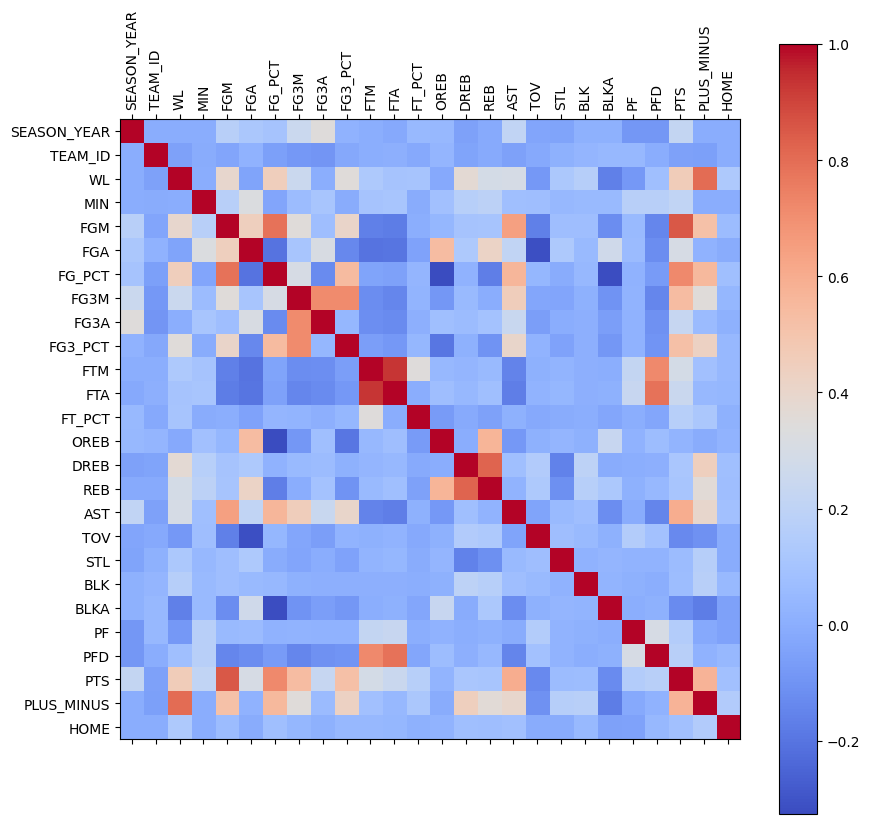

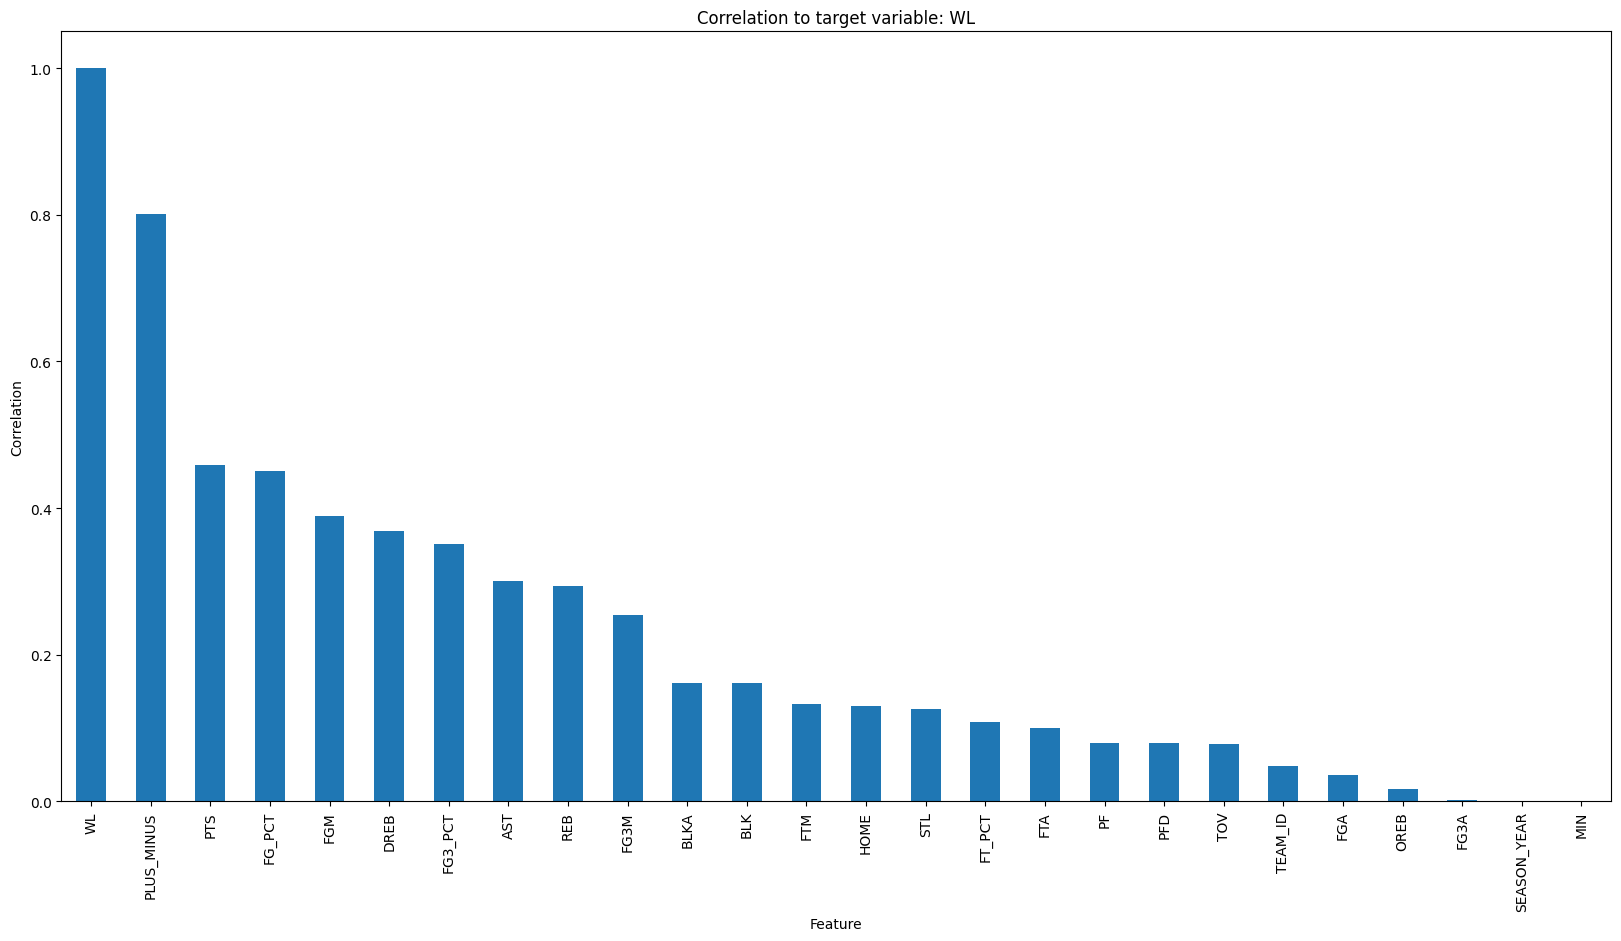

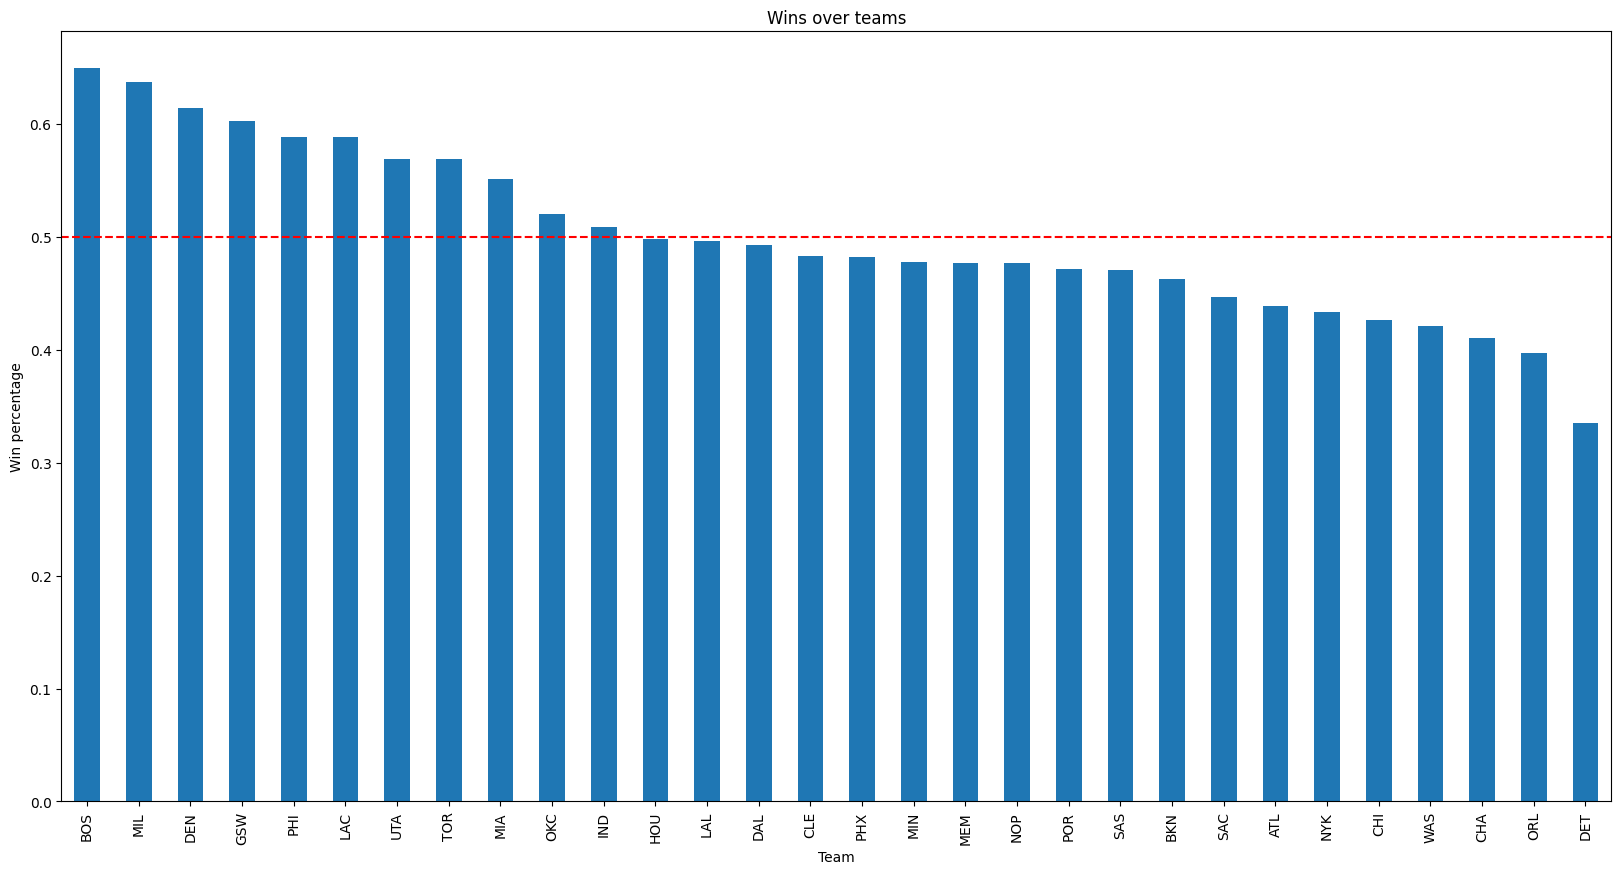

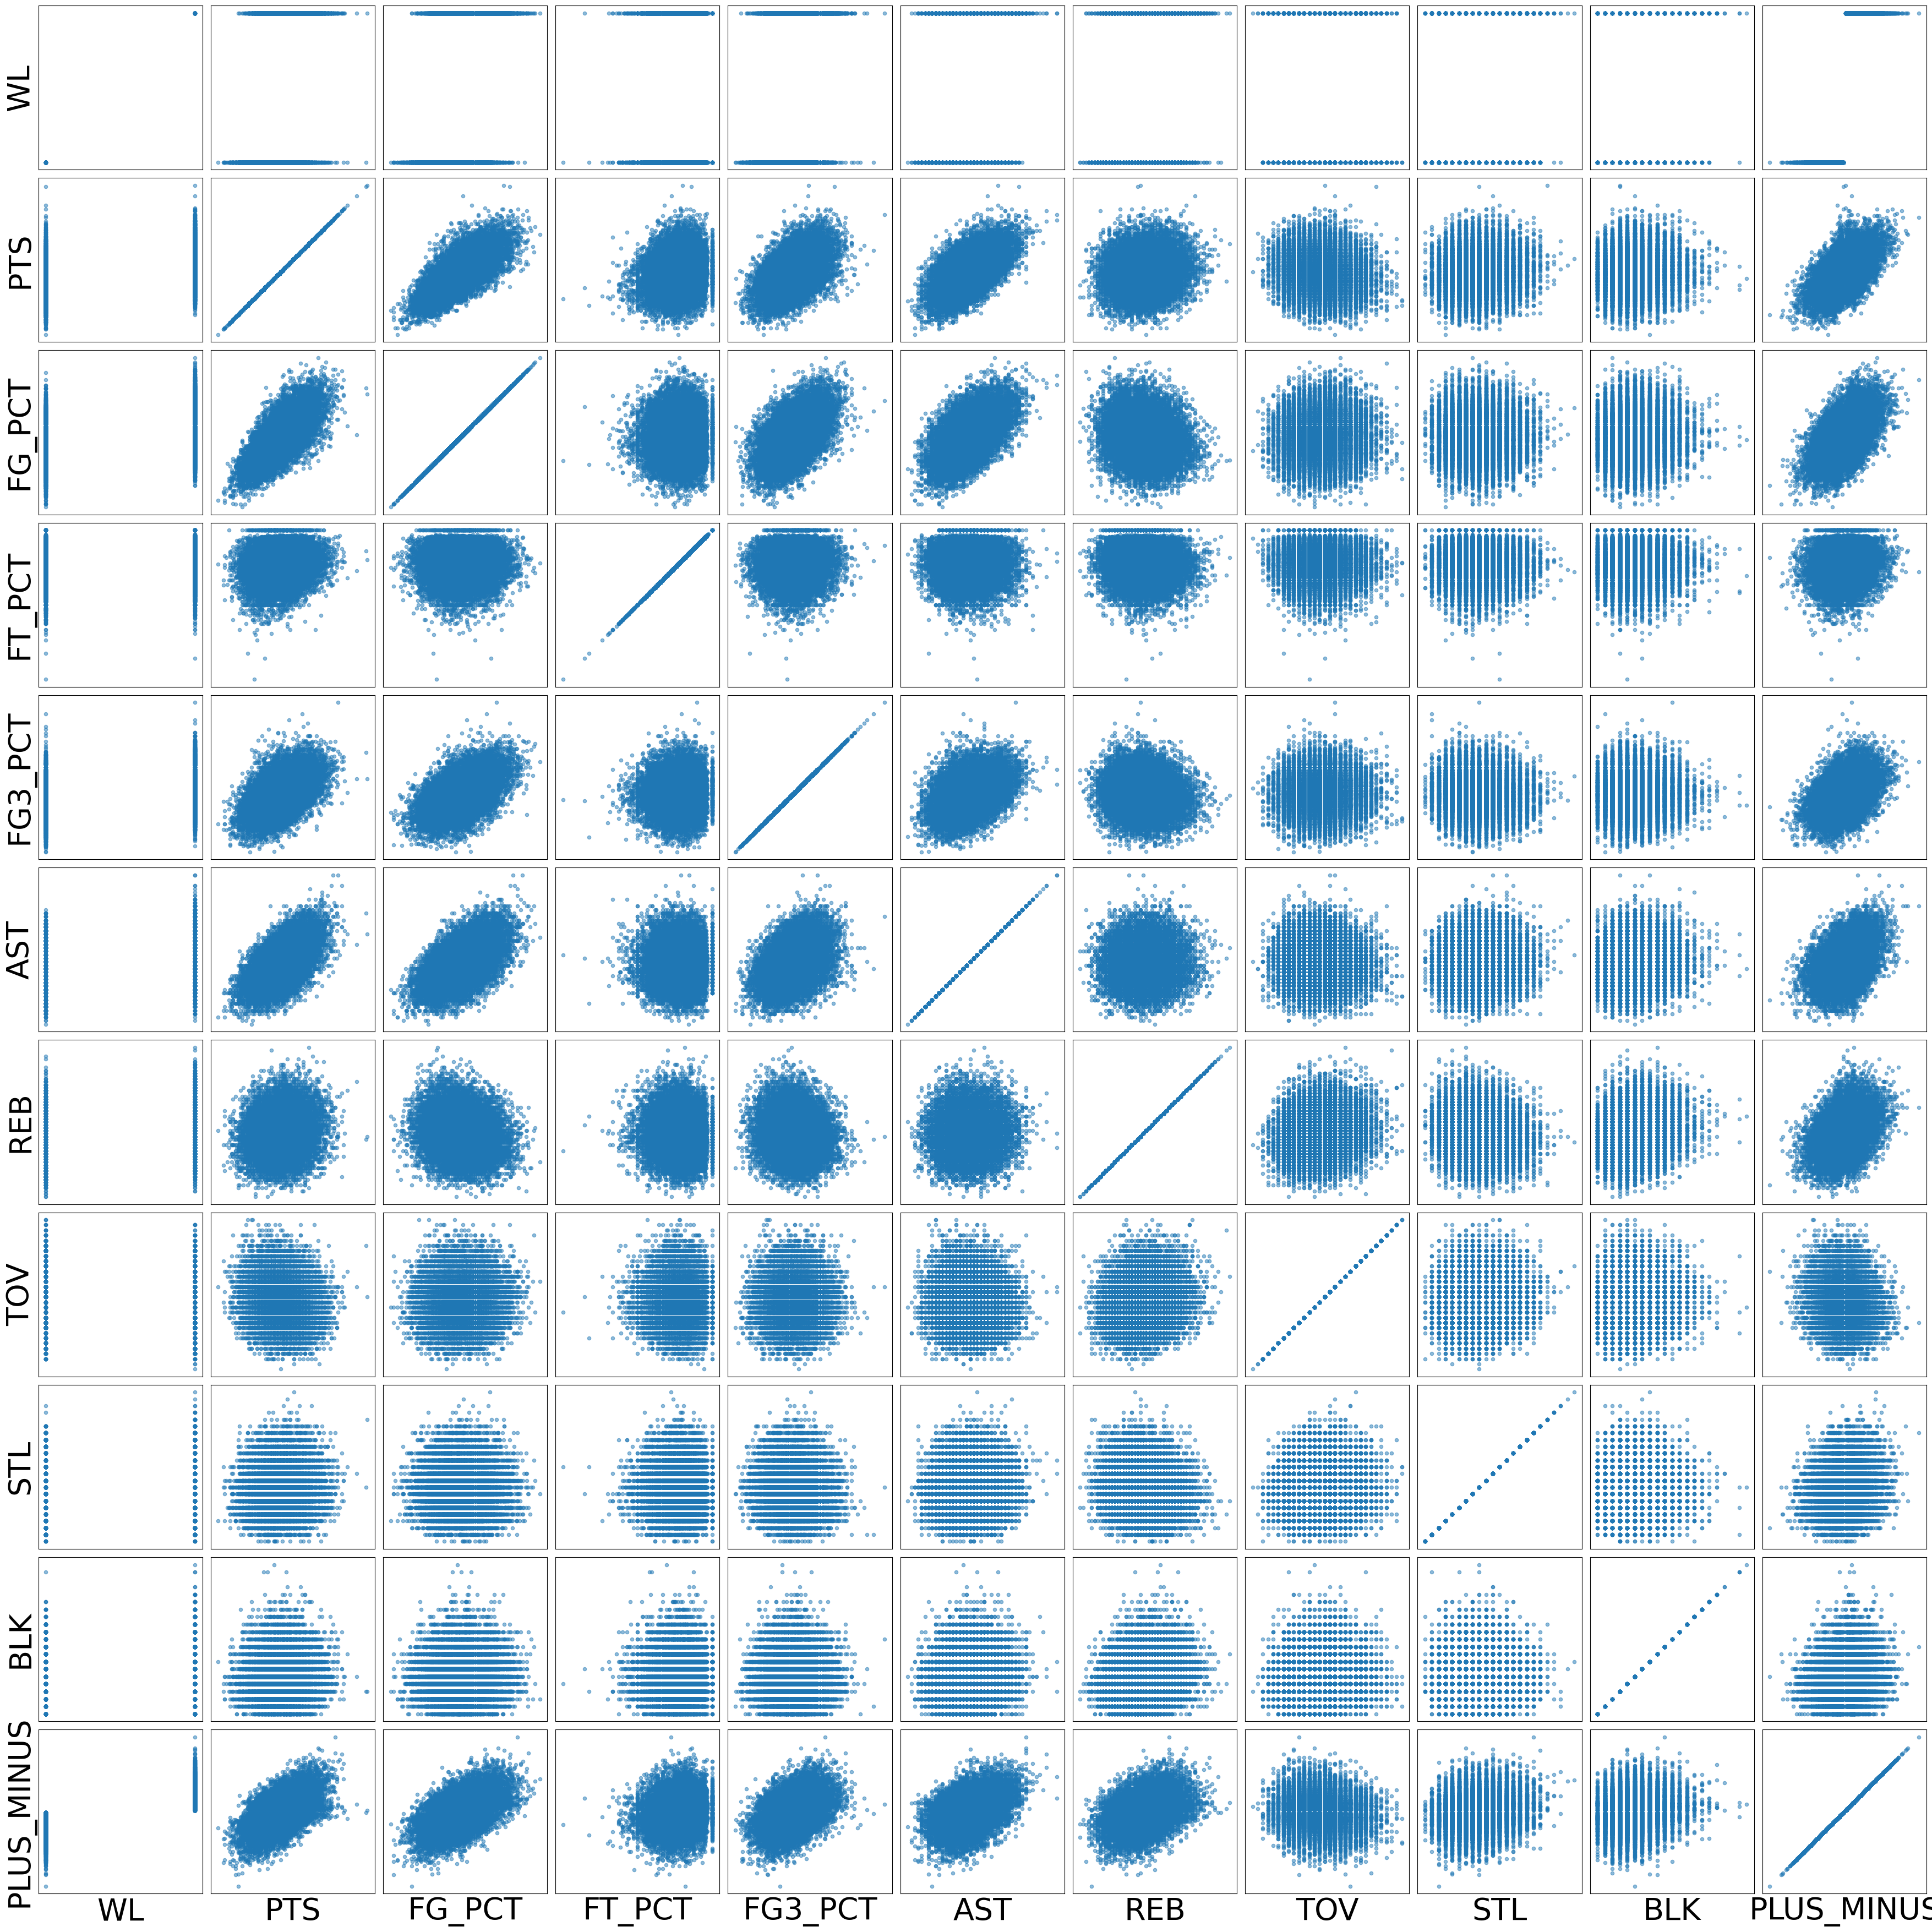

In [37]:
log.info("Percentage of home wins")
log.info(np.round(df_team['WL'].mean(), 4))

plot_correlation_matrix(df_team_converted)
plot_correlation_to_target(df_team_converted, 'WL')
plot_wins_over_teams(df_team_converted)
plot_scatter(df_team_converted)

## Model Building

In [40]:
def calc_metrics(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    metrics = {
        'accuracy': accuracy,
        'f1': f1,
        'balanced_accuracy': balanced_accuracy
    }
    log.info(f"Metrics: {metrics}")
    return metrics

def plot_proba_hist(y_prob):
    # Plot histogram of probabilities
    plt.hist(y_prob[:, 1], bins=20)
    plt.xlabel('Probability of win')
    plt.ylabel('Frequency')
    plt.savefig(EVAL_DIR+"/probability_histogram.png")
    plt.close()


def plot_feature_importance(model, X):
    # Plot feature importance
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    else:
        log.info("Model does not have feature_importances_ attribute")
        return
    features = X.columns
    indices = feature_importances.argsort()[::-1]
    indices = indices[:10]

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances")
    plt.bar(range(len(indices)), feature_importances[indices], align="center")
    plt.xticks(range(len(indices)), features[indices], rotation=90)
    plt.tight_layout()
    plt.savefig(EVAL_DIR+"/feature_importance.png")
    plt.close()


def plot_prediction_hist(y_test, y_pred):
    # Plot histogram of predictions
    width = 0.25
    bins = np.arange(len(np.unique(y_test))) - width / 2

    plt.bar(bins - width, np.bincount(y_test), width=width, alpha=0.5, label='True')
    plt.bar(bins + width, np.bincount(y_pred), width=width, alpha=0.5, label='Predictions')
    plt.xticks(bins, np.unique(y_test))
    plt.legend(loc='upper right')
    plt.savefig(EVAL_DIR+"/prediction_histogram.png")
    plt.close()


def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.matshow(cm, cmap=plt.cm.Blues)
    # add values in plot
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(x=j, y=i, s=cm[i, j], va='center', ha='center')
    plt.colorbar()
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(EVAL_DIR+"/confusion_matrix.png")
    plt.close()


def plot_roc_curve(y_test, y_prob):
    fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.savefig(EVAL_DIR+"/roc_curve.png")
    plt.close()


def plot_precision_recall_curve(y_test, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.savefig(EVAL_DIR+"/precision_recall_curve.png")
    plt.close()


In [ ]:
def perform_grid_search(clf, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy', cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_clf = grid_search.best_estimator_
    print(f"Best parameters found: {grid_search.best_params_}")
    return best_clf


def train_model(clf, data: pd.DataFrame, param_grid=None, include_injuries=False):

    # Split the data into features and target
    X = data.drop(columns=['WL', 'SEASON_YEAR', 'GAME_ID', 'GAME_DATE', 'TEAM_ID_HOME', 'TEAM_ID_AWAY'], inplace=False)
    if not include_injuries:
        X = X.drop(columns=['INJURED_PLAYERS_HOME_STATS', 'INJURED_PLAYERS_AWAY_STATS'], inplace=False)
    if "Unnamed: 0" in X.columns:
        X = X.drop(columns=['Unnamed: 0'], inplace=False)
    y = data['WL']

    log.info("Train Data")
    log.info(X.head())

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

    if param_grid is not None:
        best_clf = perform_grid_search(clf, param_grid, X_train, y_train)
    else:
        best_clf = clf

    best_clf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = best_clf.predict(X_test)
    y_prob = best_clf.predict_proba(X_test)

    metrics = calc_metrics(y_test, y_pred)

    
    plot_feature_importance(best_clf, X)
    plot_prediction_hist(y_test, y_pred)
    plot_proba_hist(y_prob)
    plot_confusion_matrix(y_test, y_pred)
    plot_roc_curve(y_test, y_prob)
    plot_precision_recall_curve(y_test, y_prob)


clf = GradientBoostingClassifier(random_state=SEED)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

train_model(clf, df_full, param_grid=param_grid, include_injuries=True)

2025-01-26 13:51:41: INFO: Train Data
2025-01-26 13:51:41: INFO:    FGM_AGG_5_HOME  FGA_AGG_5_HOME  FG_PCT_AGG_5_HOME  FG3M_AGG_5_HOME  \
0            36.4            86.0             0.4220              8.2   
1            37.4            87.6             0.4270              8.2   
2            36.4            85.4             0.4268              7.2   
3            36.8            85.0             0.4338              7.2   
4            41.6            84.8             0.4896              9.0   

   FG3A_AGG_5_HOME  FG3_PCT_AGG_5_HOME  FTM_AGG_5_HOME  FTA_AGG_5_HOME  \
0             26.8              0.3028            12.0            16.8   
1             28.2              0.2888            11.0            16.8   
2             25.6              0.2838            15.0            21.2   
3             25.4              0.2764            16.2            22.0   
4             25.6              0.3430            20.0            25.8   

   FT_PCT_AGG_5_HOME  OREB_AGG_5_HOME  ...  STL_AGG

### Detailed Evaluation